# Analyse et préparation des données images

## Initialisations

In [5]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [8]:
DATA_DIR = Path("../.data/mri_dataset_brain_cancer_oc")

LABELED_DIR = DATA_DIR / "avec_labels"
UNLABELED_DIR = DATA_DIR / "sans_label"

CANCER_DIR = LABELED_DIR / "cancer"
NORMAL_DIR = LABELED_DIR / "normal"

print(DATA_DIR.resolve())

/workspace/.data/mri_dataset_brain_cancer_oc


## Analyse du dataset
### Inventaire des fichiers

In [9]:
def list_images(folder, exts={".png", ".jpg", ".jpeg"}):
    return [p for p in folder.glob("**/*") if p.suffix.lower() in exts]

cancer_images = list_images(CANCER_DIR)
normal_images = list_images(NORMAL_DIR)
unlabeled_images = list_images(UNLABELED_DIR)

print(f"Images cancer : {len(cancer_images)}")
print(f"Images normales : {len(normal_images)}")
print(f"Images sans label : {len(unlabeled_images)}")

Images cancer : 50
Images normales : 50
Images sans label : 1406


### Résolution et canaux

In [10]:
def get_image_stats(paths, max_images=50):
    sizes = []
    modes = []
    errors = 0

    for p in paths[:max_images]:
        try:
            with Image.open(p) as img:
                sizes.append(img.size)  # (width, height)
                modes.append(img.mode)  # 'L', 'RGB', etc.
        except Exception as e:
            print(f"Erreur sur {p}: {e}")
            errors += 1

    return sizes, modes, errors

sizes_cancer, modes_cancer, err_cancer = get_image_stats(cancer_images)
sizes_normal, modes_normal, err_normal = get_image_stats(normal_images)
sizes_unlab, modes_unlab, err_unlab = get_image_stats(unlabeled_images)

print("Erreurs lecture - cancer:", err_cancer)
print("Erreurs lecture - normal:", err_normal)
print("Erreurs lecture - sans labels:", err_unlab)

def summarize_sizes(sizes, modes, label):
    print(f"\n=== {label} ===")
    print("Nb d'images analysées :", len(sizes))
    print("Top 5 tailles les plus fréquentes :")
    for (w, h), count in Counter(sizes).most_common(5):
        print(f"  {w}x{h} -> {count} images")
    print("Modes (canaux) :")
    for m, count in Counter(modes).most_common():
        print(f"  {m} -> {count}")

summarize_sizes(sizes_cancer, modes_cancer, "CANCER")
summarize_sizes(sizes_normal, modes_normal, "NORMAL")
summarize_sizes(sizes_unlab, modes_unlab, "SANS LABELS")

Erreurs lecture - cancer: 0
Erreurs lecture - normal: 0
Erreurs lecture - sans labels: 0

=== CANCER ===
Nb d'images analysées : 50
Top 5 tailles les plus fréquentes :
  512x512 -> 50 images
Modes (canaux) :
  RGB -> 50

=== NORMAL ===
Nb d'images analysées : 50
Top 5 tailles les plus fréquentes :
  512x512 -> 50 images
Modes (canaux) :
  RGB -> 50

=== SANS LABELS ===
Nb d'images analysées : 50
Top 5 tailles les plus fréquentes :
  512x512 -> 50 images
Modes (canaux) :
  RGB -> 50


### Exploration visuelle

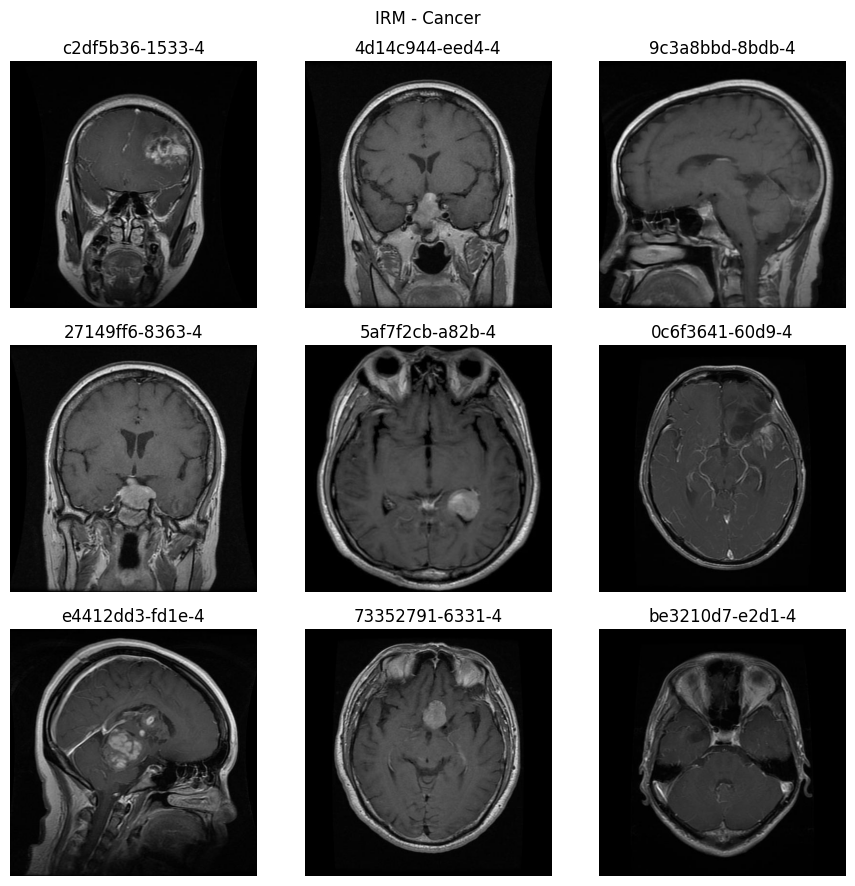

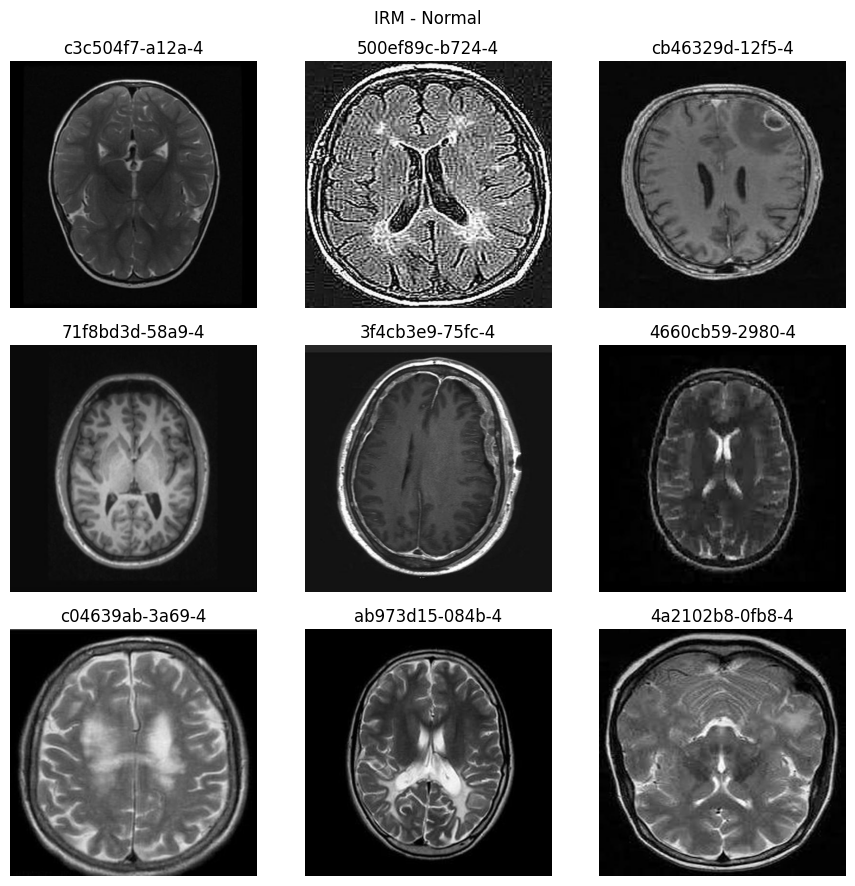

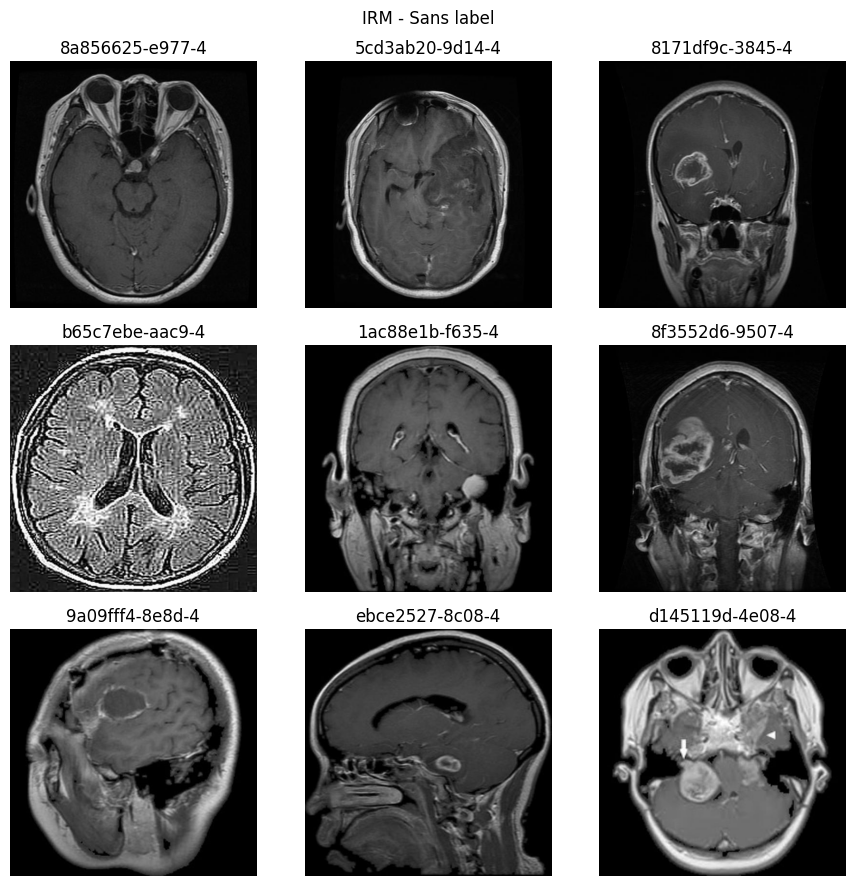

In [13]:
def show_sample(images, n=9, title=""):
    n = min(n, len(images))
    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(3*cols, 3*rows))
    for i, p in enumerate(images[:n]):
        with Image.open(p) as img:
            plt.subplot(rows, cols, i+1)
            plt.imshow(img, cmap="gray" if img.mode != "RGB" else None)
            plt.axis("off")
            plt.title(p.name[:15])
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_sample(cancer_images, n=9, title="IRM - Cancer")
print("\n\n\n\n\n\n")
show_sample(normal_images, n=9, title="IRM - Normal")
print("\n\n\n\n\n\n")
show_sample(unlabeled_images, n=9, title="IRM - Sans label")

### Bilan exploratoire

#### Format des images
Les IRM ont toutes une taille de 512×512 pixels et sont encodées en RGB, mais en pratique elles sont en niveaux de gris (les trois canaux sont visuellement similaires).

#### Points de vue et cadrage
Les images présentent différents plans de coupe (axial, sagittal, coronal) et un cadrage variable : le cerveau n’est pas toujours centré et le niveau de zoom change d’une image à l’autre.

#### Visibilité des tumeurs
Certaines tumeurs sont très nettes et bien délimitées, tandis que d’autres sont plus discrètes, avec des contrastes moins marqués, ce qui rend la séparation visuelle cancer/normal parfois subtile.

#### Implications pour la suite
Cette hétérogénéité de vue, cadrage et contraste devra être gérée par un prétraitement adapté (redimensionnement, normalisation, éventuellement data augmentation) avant l’extraction de features et la modélisation.